Econml without lag features

Both temp and rh are variable

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML

In [15]:
df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/final.csv")

In [16]:
# Drop unwanted columns
df = df.drop(columns=['_id_x', '_id_y'])

# Datetime handling
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Time-of-day feature
df['hour'] = df['datetime'].dt.hour

# Drop NaN
df = df.dropna()

In [17]:
df.head()

,datetime,wdLoad,temp,rh,hour
0,2017-12-31 18:30:00+00:00,227.02,19.12,68.06,18
1,2017-12-31 18:45:00+00:00,226.78,19.06,68.14,18
2,2017-12-31 19:00:00+00:00,225.58,18.96,68.32,19
3,2017-12-31 19:15:00+00:00,224.05,18.97,66.54,19
4,2017-12-31 19:30:00+00:00,222.34,18.90,67.32,19


In [18]:
# Outcome
Y = df['wdLoad'].values

# Treatments (multiple)
T = df[['temp', 'rh']].values

# Controls (ONLY time-of-day)
X = df[['hour']].values

In [19]:
model = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model.fit(Y, T, X=X)

In [20]:

effects = model.const_marginal_effect(X)
print("Effects shape:", effects.shape)

Effects shape: (288897, 2)


In [21]:
ate_temp = np.mean(effects[:,0])
ate_rh = np.mean(effects[:,1])

print("ATE (Temperature):", ate_temp)
print("ATE (Humidity):", ate_rh)

ATE (Temperature): 8.528953430430779
ATE (Humidity): 0.4232110991323326


In [22]:
df_effect = pd.DataFrame(X, columns=['hour'])

df_effect['temp_effect'] = effects[:,0]
df_effect['rh_effect'] = effects[:,1]

print(df_effect.groupby('hour')['temp_effect'].mean())
print(df_effect.groupby('hour')['rh_effect'].mean())

hour
0      4.705553
1      4.655454
2      6.046234
3      7.875358
4      9.644117
5     10.796945
6     11.723873
7     12.258468
8     12.635379
9     12.941546
10    11.894299
11    10.331420
12     8.498787
13     7.639853
14     8.207735
15     7.903998
16     7.349744
17     8.148625
18     8.518235
19     7.963546
20     7.160058
21     6.399285
22     5.957552
23     5.445228
Name: temp_effect, dtype: float64
hour
0     0.045723
1     0.027143
2     0.056658
3     0.266624
4     0.579555
5     0.881151
6     1.163560
7     1.325127
8     1.395264
9     1.356943
10    1.085593
11    0.834968
12    0.543997
13    0.273755
14    0.175807
15    0.074303
16    0.086345
17    0.075141
18    0.011375
19   -0.047846
20   -0.029900
21   -0.030243
22    0.003803
23    0.003372
Name: rh_effect, dtype: float64


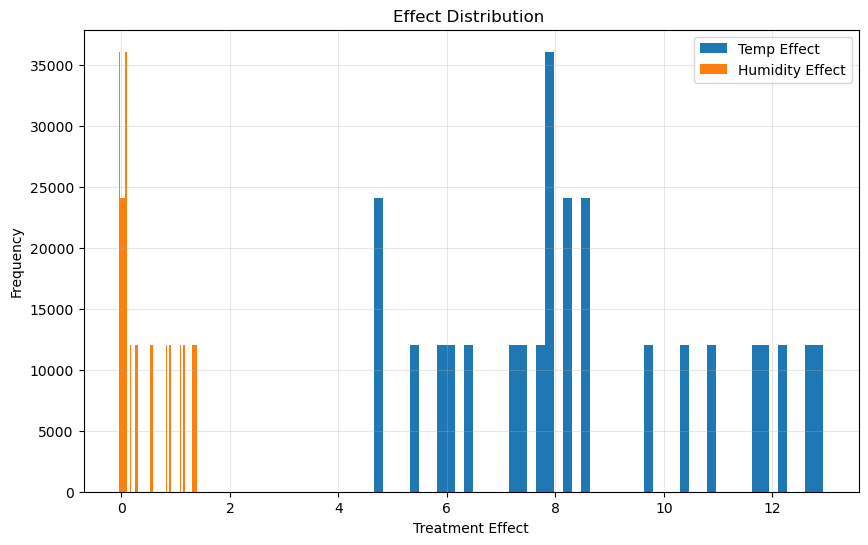

In [25]:
plt.figure(figsize=(10,6))

plt.hist(effects[:,0], bins=50, label='Temp Effect')
plt.hist(effects[:,1], bins=50, label='Humidity Effect')

plt.xlabel("Treatment Effect")
plt.ylabel("Frequency")
plt.title("Effect Distribution ")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

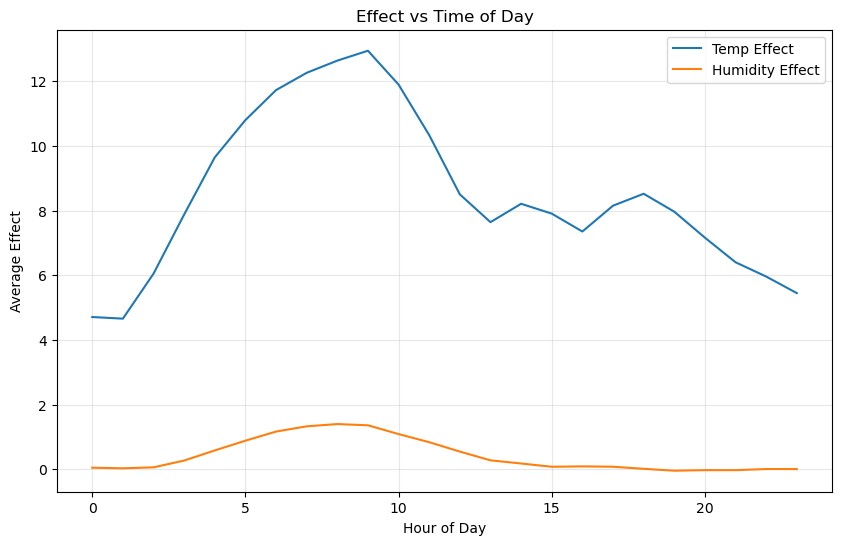

In [24]:
temp_by_hour = df_effect.groupby('hour')['temp_effect'].mean()
rh_by_hour = df_effect.groupby('hour')['rh_effect'].mean()

plt.figure(figsize=(10,6))

plt.plot(temp_by_hour.index, temp_by_hour.values, label='Temp Effect')
plt.plot(rh_by_hour.index, rh_by_hour.values, label='Humidity Effect')

plt.xlabel("Hour of Day")
plt.ylabel("Average Effect")
plt.title("Effect vs Time of Day")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Temp as variable

In [26]:
Y = df['wdLoad'].values

T_temp = df['temp'].values   # ✅ Treatment

# humidity is in X → treated as constant/control
X_temp = df[['hour', 'rh']].values

In [27]:
model_temp = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)
model_temp.fit(Y, T_temp, X=X_temp)

In [28]:
effects_temp = model_temp.effect(X_temp)

ate_temp = np.mean(effects_temp)

print("ATE (Temperature):", ate_temp)

ATE (Temperature): 9.47257657377831


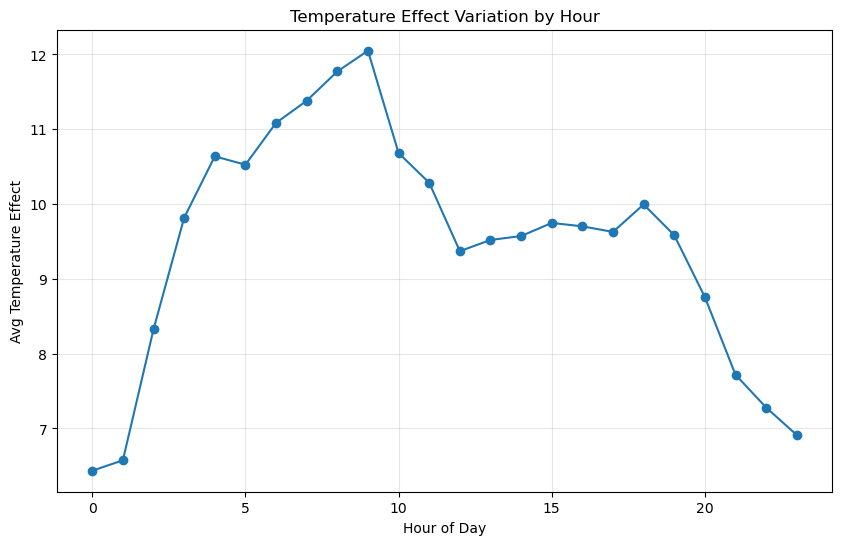

In [33]:
import pandas as pd

df_temp = pd.DataFrame(X_temp, columns=['hour','rh'])
df_temp['effect'] = effects_temp

temp_by_hour = df_temp.groupby('hour')['effect'].mean()

plt.figure(figsize=(10,6))

plt.plot(temp_by_hour.index, temp_by_hour.values, marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Avg Temperature Effect")
plt.title("Temperature Effect Variation by Hour")

plt.grid(alpha=0.3)
plt.show()

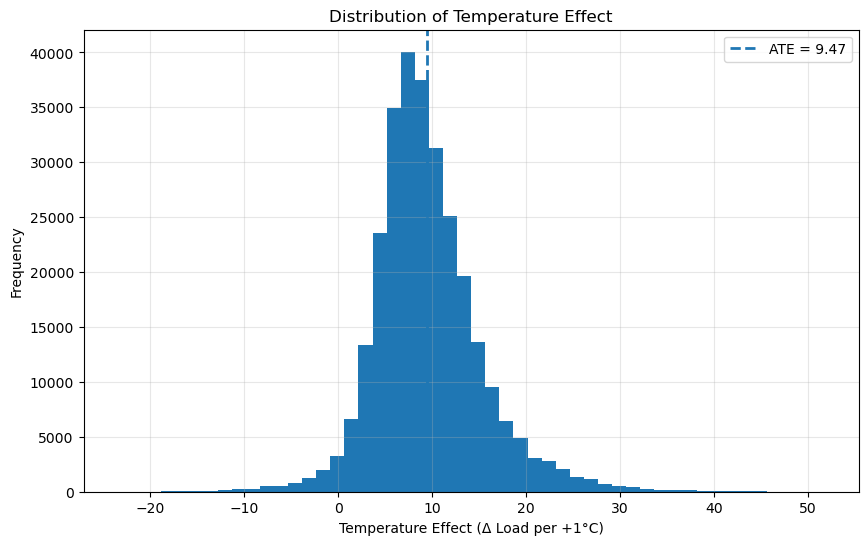

In [35]:
import matplotlib.pyplot as plt
import numpy as np

ate_temp = np.mean(effects_temp)

plt.figure(figsize=(10,6))

plt.hist(effects_temp, bins=50)

plt.axvline(ate_temp, linestyle='--', linewidth=2, label=f'ATE = {ate_temp:.2f}')

plt.xlabel("Temperature Effect (Δ Load per +1°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature Effect")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Humidity as variable

In [29]:
T_rh = df['rh'].values   # ✅ Treatment

# temperature is now control
X_rh = df[['hour', 'temp']].values

In [30]:
model_rh = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model_rh.fit(Y, T_rh, X=X_rh)

In [31]:
effects_rh = model_rh.effect(X_rh)

ate_rh = np.mean(effects_rh)

print("ATE (Humidity):", ate_rh)

ATE (Humidity): 0.4945463221148647


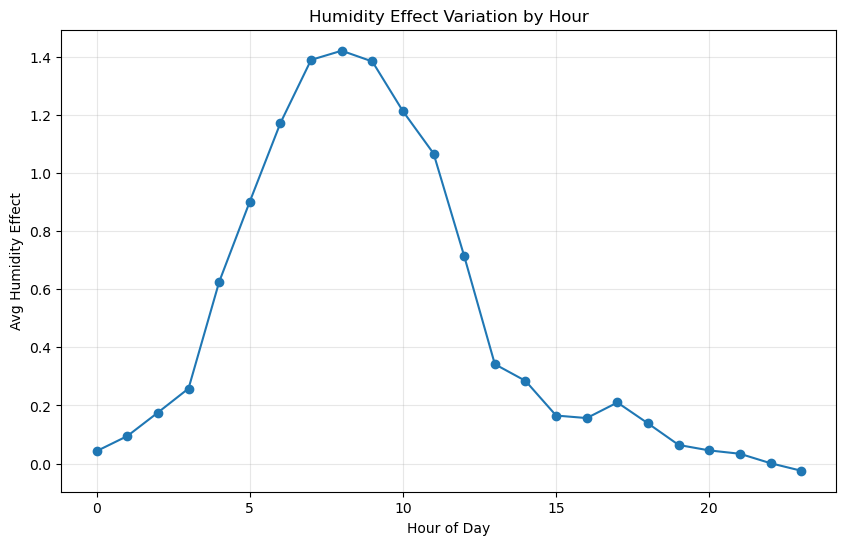

In [32]:
df_rh = pd.DataFrame(X_rh, columns=['hour','temp'])
df_rh['effect'] = effects_rh

rh_by_hour = df_rh.groupby('hour')['effect'].mean()

plt.figure(figsize=(10,6))

plt.plot(rh_by_hour.index, rh_by_hour.values, marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Avg Humidity Effect")
plt.title("Humidity Effect Variation by Hour")

plt.grid(alpha=0.3)
plt.show()

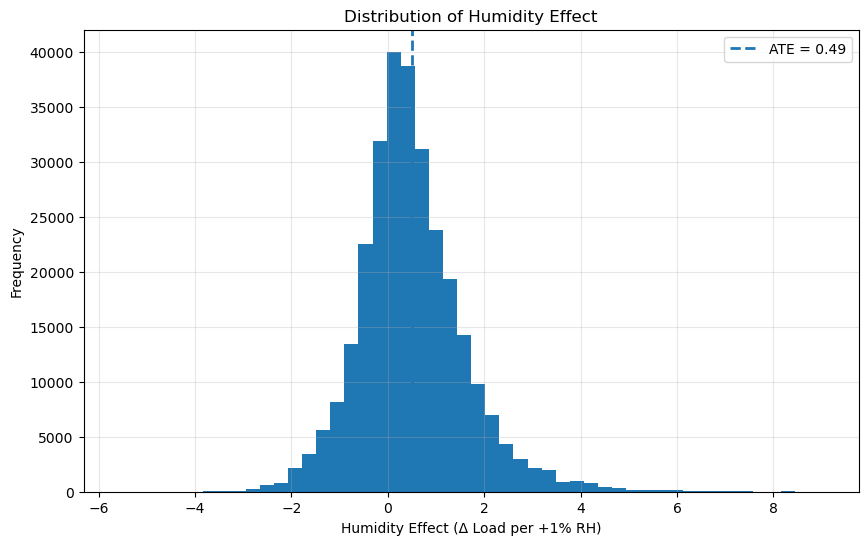

In [34]:
ate_rh = np.mean(effects_rh)

plt.figure(figsize=(10,6))

plt.hist(effects_rh, bins=50)

plt.axvline(ate_rh, linestyle='--', linewidth=2, label=f'ATE = {ate_rh:.2f}')

plt.xlabel("Humidity Effect (Δ Load per +1% RH)")
plt.ylabel("Frequency")
plt.title("Distribution of Humidity Effect")

plt.legend()
plt.grid(alpha=0.3)

plt.show()